# LeetCode #538: Convert BST to Greater Tree

https://leetcode.com/problems/convert-bst-to-greater-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (collect + prefix sum)** | $O(n)$ | $O(n)$ |
| **Optimal: Reverse In-order Traversal ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (collect + prefix sum)
In-order traversal collects all values into a sorted array. Compute a suffix sum array, then traverse again to assign updated values. Requires $O(n)$ extra space for the value array.

### Optimal: Reverse In-order Traversal ★
A BST visited right→node→left yields values in descending order. Maintain a single running suffix sum; add it to each node's value in-place. No extra array is needed — only the recursion stack of depth $h$.

**Why this is better than Brute Force:** Eliminates the $O(n)$ value array by folding the suffix sum computation into a single reverse traversal.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 100]$
* $0 \le \text{Node.val} \le 100$
* All `Node.val` are unique


## Solutions

### C#

In [ ]:
public TreeNode ConvertBST(TreeNode root) {
    int suffix = 0;
    void Traverse(TreeNode node) {
        if (node == null) return;
        // Visit right subtree first (descending order)
        Traverse(node.right);
        // Accumulate running suffix sum and update node value
        suffix += node.val;
        node.val = suffix;
        Traverse(node.left);
    }
    Traverse(root);
    return root;
}

### Python

In [ ]:
def convert_bst(root):
    suffix = 0

    def traverse(node):
        nonlocal suffix
        if not node:
            return
        # Visit right subtree first (descending order)
        traverse(node.right)
        # Accumulate running suffix sum and update node value
        suffix += node.val
        node.val = suffix
        traverse(node.left)

    traverse(root)
    return root

### Go

In [ ]:
func convertBST(root *TreeNode) *TreeNode {
    suffix := 0
    var traverse func(*TreeNode)
    traverse = func(node *TreeNode) {
        if node == nil { return }
        // Visit right subtree first (descending order)
        traverse(node.Right)
        // Accumulate running suffix sum and update node value
        suffix += node.Val
        node.Val = suffix
        traverse(node.Left)
    }
    traverse(root)
    return root
}

### Rust

In [ ]:
pub fn convert_bst(root: Option<Box<TreeNode>>) -> Option<Box<TreeNode>> {
    fn traverse(node: &mut Option<Box<TreeNode>>, suffix: &mut i32) {
        if let Some(n) = node {
            // Visit right subtree first (descending order)
            traverse(&mut n.right, suffix);
            // Accumulate running suffix sum and update node value
            *suffix += n.val;
            n.val = *suffix;
            traverse(&mut n.left, suffix);
        }
    }
    let mut root = root;
    traverse(&mut root, &mut 0);
    root
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [4,1,6,0,2,5,7,null,null,null,3,null,null,null,8]`
Reverse in-order visits: 8,7,6,5,4,3,2,1,0. Running suffix: 8→15→21→26→30→33→35→36→36. Node 4 becomes 30 (sum of 4+5+6+7+8).

**2. Slightly Complex**
**Input:** `root = [2,0,3]`
Reverse in-order: visit 3 → suffix=3, node becomes 3. Visit 2 → suffix=5, node becomes 5. Visit 0 → suffix=5, node becomes 5. Result: [5,5,3].

**3. Edge Case: Time Factor**
**Input:** Right-skewed tree `[1,null,2,null,3,...,null,n]`
Reverse in-order visits the deepest node first and walks up the chain — all $n$ nodes are visited exactly once. No shortcuts possible: $O(n)$ is unavoidable.

**4. Edge Case: Space Factor**
**Input:** Perfectly balanced tree of height $h = \log n$
Recursion depth is $O(h) = O(\log n)$ — the call stack holds at most $h$ frames. Compare with the brute-force $O(n)$ array; the stack is far smaller for large balanced trees.

**5. Almost-Impossible but Plausible**
**Input:** `root = [100]` (single node)
Reverse in-order visits only the root. Suffix = 100; node value becomes 100 (unchanged, since it's already the maximum). Return the single-node tree.


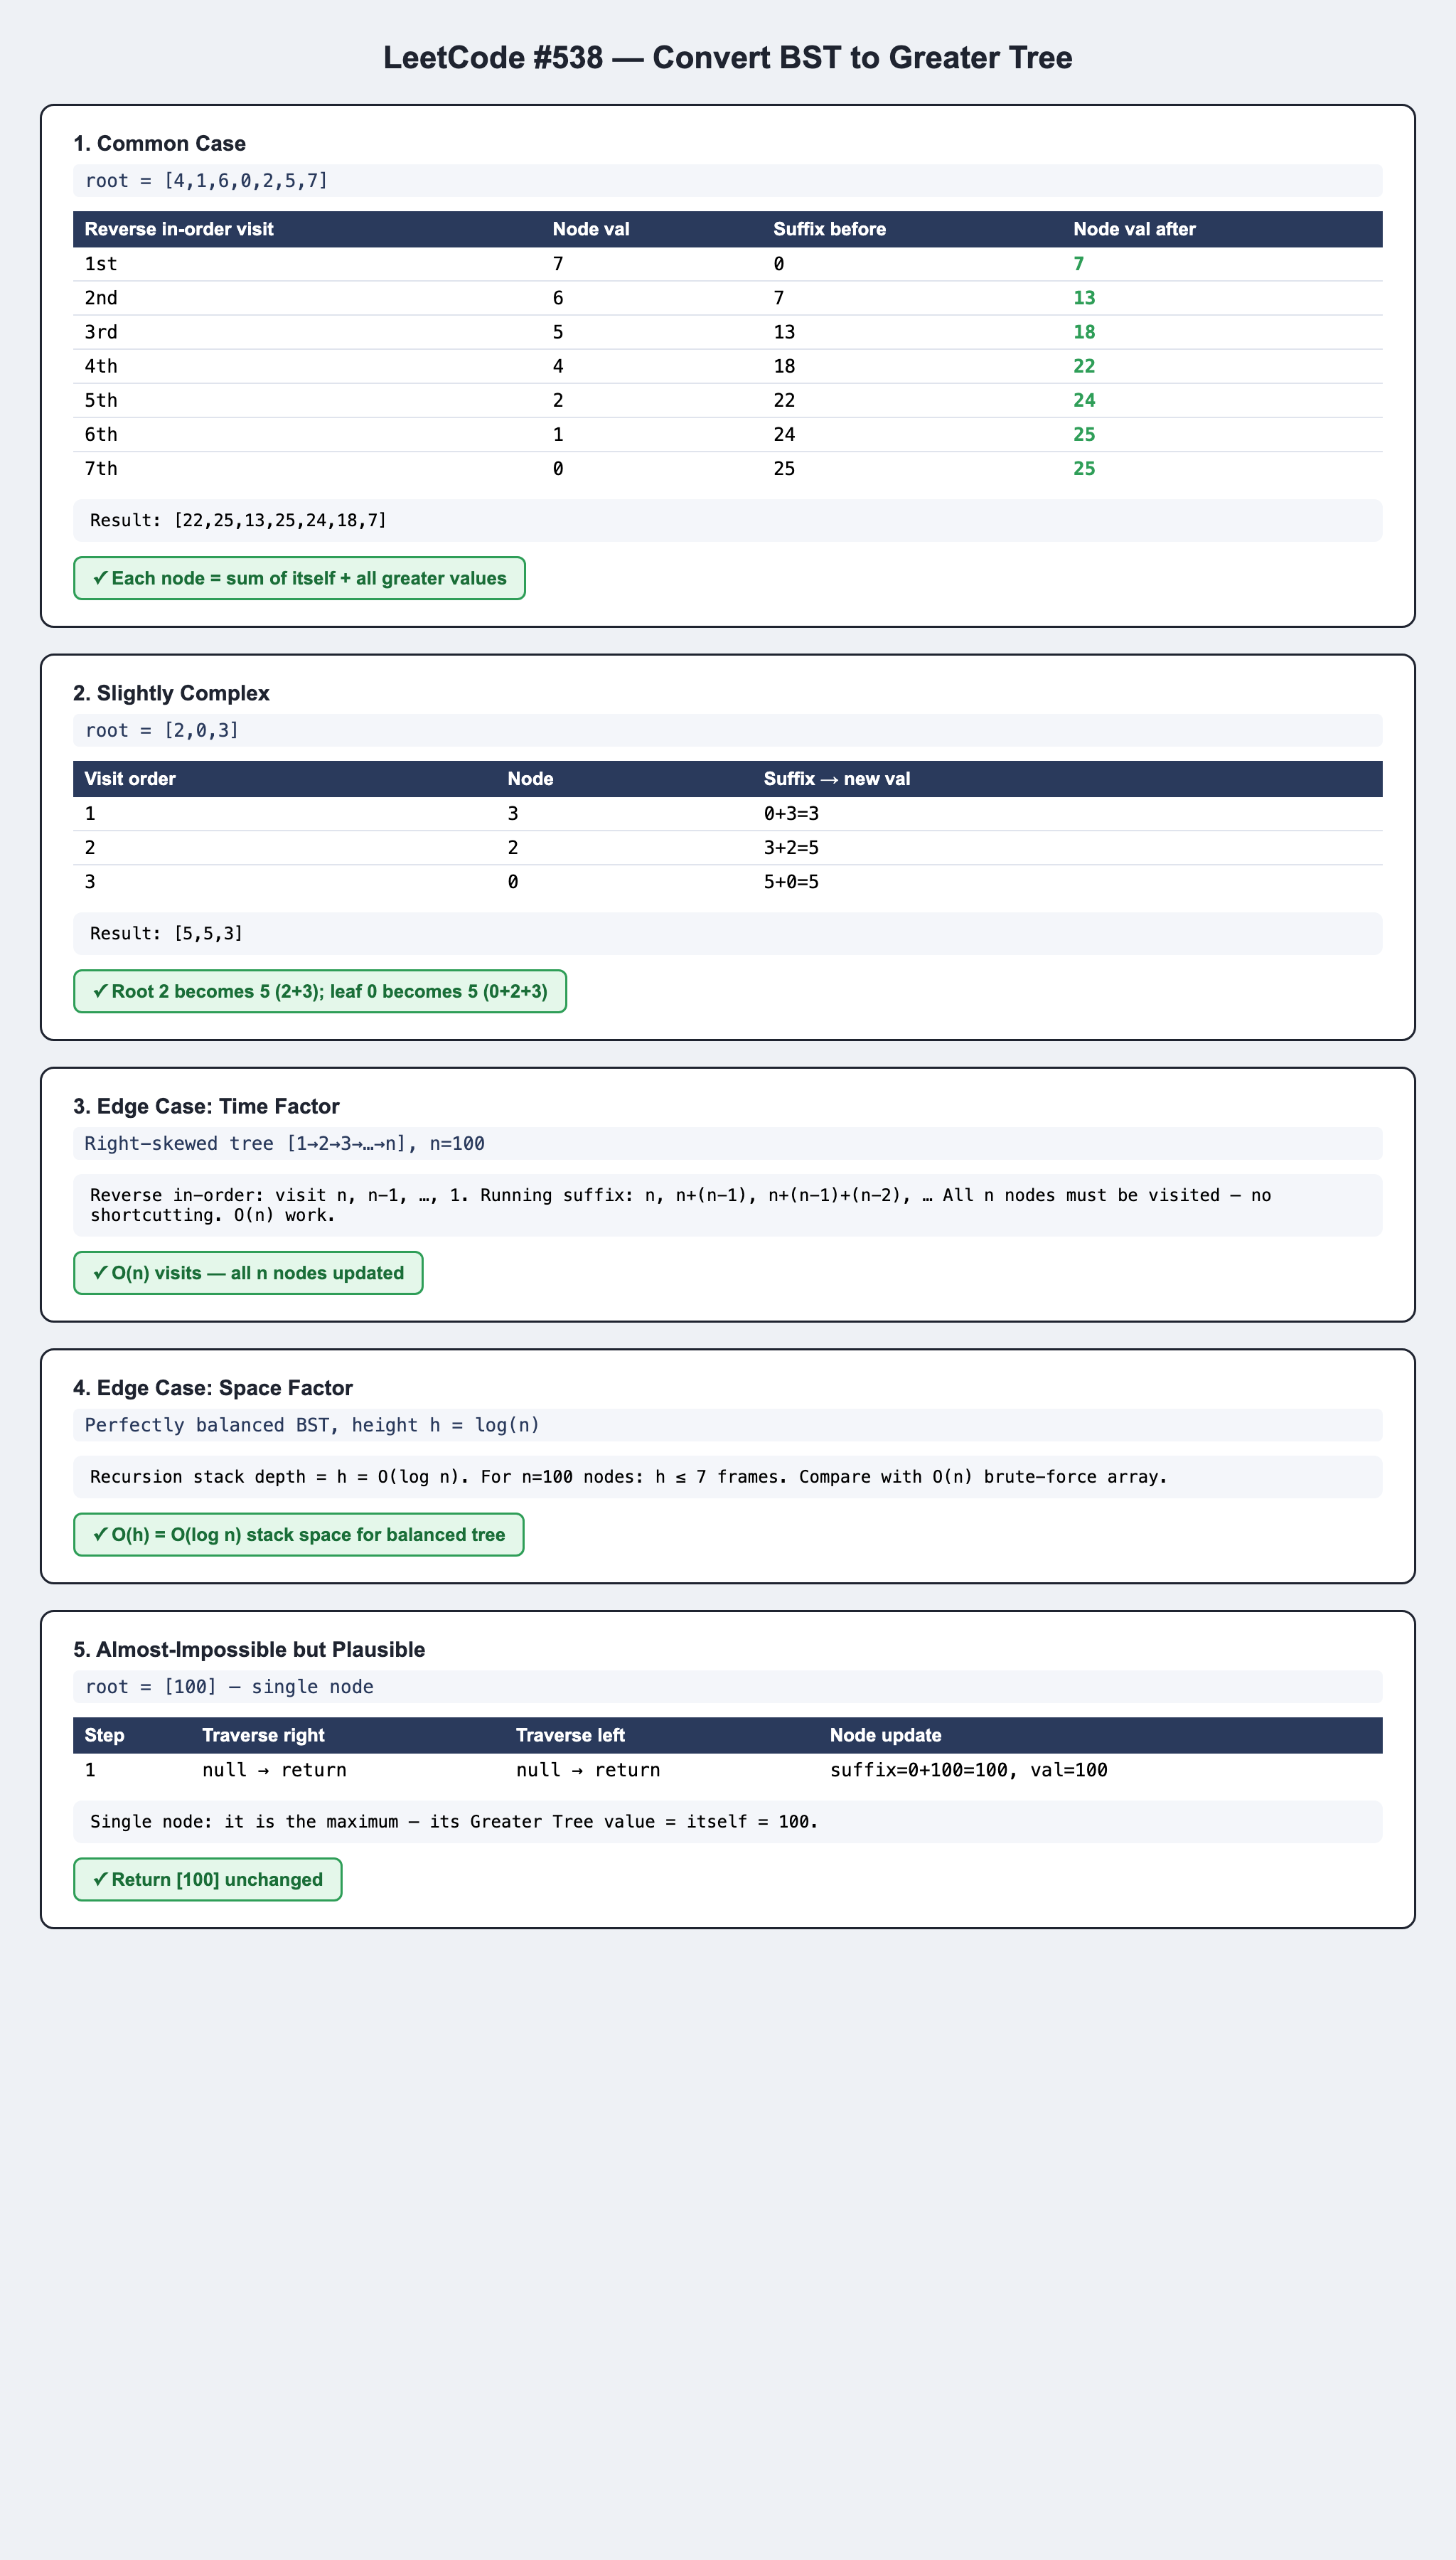